# Explode
## Explode by one columns
Transform each element of a list-like to a row, replicating index values.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

# let's clean the data type
numeric_columns = ["budget",'box_office']

for col in numeric_columns:
    df[col] = df[col].apply(pd.to_numeric, errors='coerce')

df

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000.0,2.888450e+07,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont"
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000.0,2.503418e+08,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola"
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000.0,1.006234e+09,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer"
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000.0,4.796192e+07,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo"
4,5,12 Angry Men,1957,9.0,"Crime,Drama",Approved,1h 36m,Life Is In Their Hands -- Death Is On Their Mi...,350000.0,9.550000e+02,"Henry Fonda,Lee J. Cobb,Martin Balsam,John Fie...",Sidney Lumet,Reginald Rose
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,246,The Help,2011,8.1,Drama,PG-13,2h 26m,Change begins with a whisper.,25000000.0,2.166391e+08,"Viola Davis,Emma Stone,Octavia Spencer,Bryce D...",Tate Taylor,"Tate Taylor,Kathryn Stockett"
246,247,Dersu Uzala,1975,8.2,"Adventure,Biography,Drama",G,2h 22m,There is man and beast at nature's mercy. Ther...,4000000.0,1.448000e+04,"Maksim Munzuk,Yuriy Solomin,Mikhail Bychkov,Vl...",Akira Kurosawa,"Akira Kurosawa,Yuriy Nagibin,Vladimir Arsenev"
247,248,Aladdin,1992,8.0,"Animation,Adventure,Comedy",G,1h 30m,Wish granted! (DVD re-release),NaN,NaN,"Scott Weinger,Robin Williams,Linda Larkin,Jona...","Ron Clements,John Musker","Ron Clements,John Musker,Ted Elliott"
248,249,Gandhi,1982,8.0,"Biography,Drama,History",PG,3h 11m,His Triumph Changed The World Forever.,22000000.0,5.276789e+07,"Ben Kingsley,John Gielgud,Rohini Hattangadi,Ro...",Richard Attenborough,John Briley


As you can see, the `genre` column contain multiple values. We wanted to create a new dataframe with one genre per row
### Explode genres

We notice that the `genre` column is not exactly a list, so we cannot explode it directly.

In fact, if you explode it directly, nothing really happens. See the cell below.

In [2]:
df['genre'].explode().head()

0                 Drama
1           Crime,Drama
2    Action,Crime,Drama
3           Crime,Drama
4           Crime,Drama
Name: genre, dtype: object

Therefore, we need to transform this `genre` column to lists or other iterable types.
- We can create a new column called `genre_list` using string operations we have learnt
- explode by `genre_list` instead of `genre` itself.

In [3]:
df['genre_list'] = df['genre'].str.split(",")
df[['name', 'genre_list']].head()

,name,genre_list
0,The Shawshank Redemption,[Drama]
1,The Godfather,"[Crime, Drama]"
2,The Dark Knight,"[Action, Crime, Drama]"
3,The Godfather Part II,"[Crime, Drama]"
4,12 Angry Men,"[Crime, Drama]"


In [4]:
# Checking the types and confirm the type of genre_list is list
print(type(df['genre'].iloc[0]))
print(type(df['genre_list'].iloc[0]))

<class 'str'>
<class 'list'>


In [5]:
df_exploded = df.explode('genre_list', ignore_index=True)

df_exploded[['rank', 'name','genre','genre_list']]

,rank,name,genre,genre_list
0,1,The Shawshank Redemption,Drama,Drama
1,2,The Godfather,"Crime,Drama",Crime
2,2,The Godfather,"Crime,Drama",Drama
3,3,The Dark Knight,"Action,Crime,Drama",Action
4,3,The Dark Knight,"Action,Crime,Drama",Crime
...,...,...,...,...
620,249,Gandhi,"Biography,Drama,History",Drama
621,249,Gandhi,"Biography,Drama,History",History
622,250,Dances with Wolves,"Adventure,Drama,Western",Adventure
623,250,Dances with Wolves,"Adventure,Drama,Western",Drama


Now we can inspect genres

In [6]:
df_exploded['genre_list'].value_counts()

genre_list
Drama        177
Adventure     60
Crime         51
Action        50
Comedy        45
Mystery       31
Thriller      30
Biography     29
Romance       23
War           23
Animation     23
Sci-Fi        20
Fantasy       14
Family        13
History       10
Western        7
Horror         5
Sport          5
Music          4
Film-Noir      4
Musical        1
Name: count, dtype: int64

In [9]:
# there are 21 genres

df_exploded['genre_list'].nunique()

21

<Axes: xlabel='rating', ylabel='Density'>

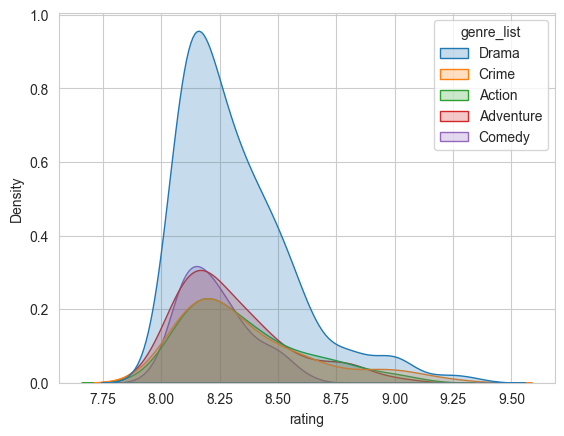

In [10]:
# Let's plot the distribution of ratings of the top five genres

sns.kdeplot(df_exploded[df_exploded['genre_list'].isin(df_exploded['genre_list'].value_counts().head(5).index)], x='rating', hue='genre_list',
            fill=True)


<Axes: ylabel='rating'>

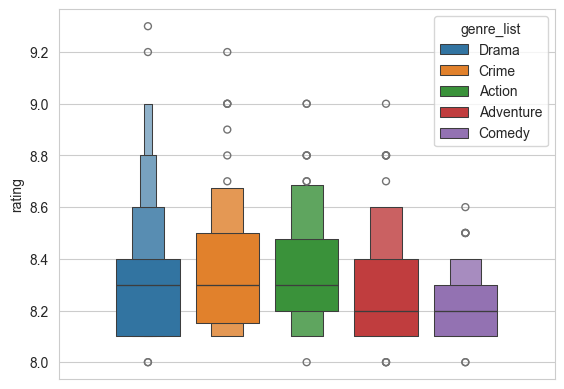

In [11]:
sns.boxenplot(df_exploded[df_exploded['genre_list'].isin(df_exploded['genre_list'].value_counts().head(5).index)], y='rating', hue='genre_list',
            gap=0.2)

### Explode actors (casts)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

# let's clean the data type
numeric_columns = ["budget",'box_office']

for col in numeric_columns:
    df[col] = df[col].apply(pd.to_numeric, errors='coerce')

df

In [ ]:
df['cast_list'] = df['casts'].str.split(",")
df_explode_cast = df.explode('cast_list', ignore_index=True)

df_explode_cast

Now we wanted to see who cast in most top movies.


In [ ]:
df_explode_cast['cast_list'].value_counts()

And who generate the most box office?

In [ ]:
cast_box_office_total = df_explode_cast.groupby('cast_list', as_index=False)['box_office'].sum().sort_values(by='box_office',ascending=False)
cast_box_office_total

### Explode by directors

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

# let's clean the data type
numeric_columns = ["budget",'box_office']

for col in numeric_columns:
    df[col] = df[col].apply(pd.to_numeric, errors='coerce')

df

In [ ]:
df['director_list']=df['directors'].str.split(",")
df['director_list']

In [ ]:
df_exploded_directors = df.explode('director_list', ignore_index=True)

In [ ]:
df_exploded_directors['director_list'].value_counts()

In [ ]:
# whose budget is the highest

df_exploded_directors.groupby("director_list", as_index=False)['budget'].sum().sort_values(by='budget',ascending=False)

## Explode by multiple columns (sequential)
### Cast and director
Let's say, we wanted to study which cast collaborate with which director the most

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

# let's clean the data type
numeric_columns = ["budget",'box_office']

for col in numeric_columns:
    df[col] = df[col].apply(pd.to_numeric, errors='coerce')

df

In [ ]:
df['cast_list'] = df['casts'].str.split(",")
df['director_list']=df['directors'].str.split(",")

df_explode_cast_director = df.explode('cast_list', ignore_index=True).explode('director_list', ignore_index=True)
df_explode_cast_director

In [ ]:
df_explode_cast_director[['cast_list','director_list']].value_counts()

In [ ]:
cast_name, director_name = 'Takashi Shimura', 'Akira Kurosawa'
df_explode_cast_director[(df_explode_cast_director['cast_list']==cast_name) & (df_explode_cast_director['director_list']==director_name)]

In [ ]:
# Another way to do it is to create a list of movies in the grouped dataframe

df_explode_cast_director.groupby(['cast_list','director_list'], as_index=False).agg(
    count=('cast_list', 'count'),
    movies=('name', list),
    box_office_million=('box_office', lambda x: (x.sum()/1_000_000))
).sort_values(by='count',ascending=False)

### Director and writer

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

# let's clean the data type
numeric_columns = ["budget",'box_office']

for col in numeric_columns:
    df[col] = df[col].apply(pd.to_numeric, errors='coerce')

df

In [ ]:
director_write_pair = (df.assign(
    director_list = df['directors'].str.split(","),
    writer_list = df['writers'].str.split(",")
).
explode('director_list', ignore_index=True).explode('writer_list', ignore_index=True).
                       groupby(['director_list','writer_list'], as_index=False).agg(
    count=('director_list', 'count'),
    movies=('name', list),
    box_office_million=('box_office', lambda x: (x.sum()/1_000_000)),
    mean_rating=('rating', 'mean')
)).assign(
    mean_box_office = lambda x: x['box_office_million']/x['count']
).sort_values(by='mean_rating',ascending=False)

director_write_pair